# Limpieza de datos para predecir `RainTomorrow`

Este notebook deja preparada la base para un modelo supervisado con Decision Tree. La idea es ejecutar cada bloque por separado y revisar el resultado antes de avanzar.

In [31]:
# Importamos las librerías que usaremos para cargar, limpiar, entrenar y evaluar el modelo.
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import display
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score, precision_score, recall_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.tree import DecisionTreeClassifier


In [32]:
# Definimos la fuente de datos, la variable objetivo y las columnas problemáticas.
DATA_URL = "https://raw.githubusercontent.com/Darygarav/base-de-datos-australia/main/weatherAUS.csv"
LOCAL_DATASET = Path("weatherAUS.csv")

LEAKAGE_COLUMNS = ["RISK_MM"]

# Esta función intenta cargar primero un archivo local y, si no existe, usa la URL.
def load_weather_data(url: str = DATA_URL) -> pd.DataFrame:
    if LOCAL_DATASET.exists():
        return pd.read_csv(LOCAL_DATASET)
    return pd.read_csv(url)

# Cargamos el dataset original para revisar su tamaño y primeras filas.
df = load_weather_data()
print(f"Filas: {df.shape[0]:,} | Columnas: {df.shape[1]}")
display(df.head())


Filas: 142,193 | Columnas: 24


,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,...,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RISK_MM,RainTomorrow
0,2008-12-01,Albury,13.4,22.9,0.6,NaN,NaN,W,44.0,W,...,22.0,1007.7,1007.1,8.0,NaN,16.9,21.8,No,0.0,No
1,2008-12-02,Albury,7.4,25.1,0.0,NaN,NaN,WNW,44.0,NNW,...,25.0,1010.6,1007.8,NaN,NaN,17.2,24.3,No,0.0,No
2,2008-12-03,Albury,12.9,25.7,0.0,NaN,NaN,WSW,46.0,W,...,30.0,1007.6,1008.7,NaN,2.0,21.0,23.2,No,0.0,No
3,2008-12-04,Albury,9.2,28.0,0.0,NaN,NaN,NE,24.0,SE,...,16.0,1017.6,1012.8,NaN,NaN,18.1,26.5,No,1.0,No
4,2008-12-05,Albury,17.5,32.3,1.0,NaN,NaN,W,41.0,ENE,...,33.0,1010.8,1006.0,7.0,8.0,17.8,29.7,No,0.2,No


In [33]:
# Calculamos cuántos valores faltantes tiene cada variable.
# Esto nos ayuda a decidir qué columnas conviene eliminar o imputar.
missing = pd.DataFrame({
    "nulos": df.isna().sum(),
    "porcentaje": (df.isna().sum() / len(df) * 100).round(2)
}).sort_values("porcentaje", ascending=False)

print("Variables con nulos:")
missing_con_nulos = missing[missing["nulos"] > 0].copy()
missing_con_nulos.insert(0, "orden", range(1, len(missing_con_nulos) + 1))
display(missing_con_nulos)


Variables con nulos:


,orden,nulos,porcentaje
Sunshine,1,67816,47.69
Evaporation,2,60843,42.79
Cloud3pm,3,57094,40.15
Cloud9am,4,53657,37.74
Pressure9am,5,14014,9.86
Pressure3pm,6,13981,9.83
WindDir9am,7,10013,7.04
WindGustDir,8,9330,6.56
WindGustSpeed,9,9270,6.52
WindDir3pm,10,3778,2.66


In [34]:
# Esta función aplica la limpieza principal para predecir RainTomorrow.
def clean_weather_data(df: pd.DataFrame):
    # Trabajamos sobre una copia para no modificar el dataset original.
    data = df.copy()

    # Convertimos Date a formato fecha y extraemos variables temporales útiles.
    data["Date"] = pd.to_datetime(data["Date"], errors="coerce")
    data["Year"] = data["Date"].dt.year
    data["Month"] = data["Date"].dt.month
    data["Day"] = data["Date"].dt.day
    data = data.drop(columns=["Date"])

    # Eliminamos columnas con demasiados nulos y una columna con fuga de información.
    HIGH_MISSING_COLUMNS = ["Sunshine", "Evaporation", "Cloud3pm", "Cloud9am"]
    drop_columns = [col for col in HIGH_MISSING_COLUMNS + LEAKAGE_COLUMNS if col in data.columns]
    data = data.drop(columns=drop_columns)

    # Nos aseguramos de que la variable objetivo exista y la convertimos a 0 y 1.
    TARGET = "RainTomorrow"
    data = data[data[TARGET].notna()].copy()
    data[TARGET] = data[TARGET].map({"No": 0, "Yes": 1})#convierte en binario y NaN
    data = data[data[TARGET].notna()].copy()
    data[TARGET] = data[TARGET].astype(int)

    # Separamos variables predictoras y variable objetivo.
    X = data.drop(columns=[TARGET])
    y = data[TARGET]
    return X, y, data

# Ejecutamos la limpieza y revisamos el resultado.
X, y, clean_df = clean_weather_data(df)

print(f"Dataset limpio: {clean_df.shape[0]:,} filas y {clean_df.shape[1]} columnas")
print(f"Variables predictoras: {X.shape[1]}")
print("Distribución de la variable objetivo:")
display(y.value_counts().rename(index={0: "No", 1: "Yes"}))
display(clean_df.head())


Dataset limpio: 142,193 filas y 21 columnas
Variables predictoras: 20
Distribución de la variable objetivo:


RainTomorrow
No     110316
Yes     31877
Name: count, dtype: int64

,Location,MinTemp,MaxTemp,Rainfall,WindGustDir,WindGustSpeed,WindDir9am,WindDir3pm,WindSpeed9am,WindSpeed3pm,...,Humidity3pm,Pressure9am,Pressure3pm,Temp9am,Temp3pm,RainToday,RainTomorrow,Year,Month,Day
0,Albury,13.4,22.9,0.6,W,44.0,W,WNW,20.0,24.0,...,22.0,1007.7,1007.1,16.9,21.8,No,0,2008,12,1
1,Albury,7.4,25.1,0.0,WNW,44.0,NNW,WSW,4.0,22.0,...,25.0,1010.6,1007.8,17.2,24.3,No,0,2008,12,2
2,Albury,12.9,25.7,0.0,WSW,46.0,W,WSW,19.0,26.0,...,30.0,1007.6,1008.7,21.0,23.2,No,0,2008,12,3
3,Albury,9.2,28.0,0.0,NE,24.0,SE,E,11.0,9.0,...,16.0,1017.6,1012.8,18.1,26.5,No,0,2008,12,4
4,Albury,17.5,32.3,1.0,W,41.0,ENE,NW,7.0,20.0,...,33.0,1010.8,1006.0,17.8,29.7,No,0,2008,12,5


## Justificacion 

1. Sunshine, Evaporation, Cloud3pm, Cloud9am (muchas nulas)
En tu propio análisis del dataset esas variables suelen tener muchísimos nulos (del orden de 40–48 % de las filas). En ese escenario:

- Imputar (mediana, media, etc.) significa inventar un valor para casi la mitad de los registros en esa variable. El modelo puede aprender patrones poco fiables o ruido que en realidad son el método de relleno, no el fenómeno meteorológico.

- Además, con tantos faltantes, la columna aporta poca información real y puede empeorar o inestabilizar el entrenamiento frente a columnas más completas.

Por eso es razonable eliminarlas: prefieres perder esa señal a cargar con demasiada incertidumbre imputada.

In [35]:
# Identificamos qué columnas son numéricas y cuáles son categóricas.
numeric_features = X.select_dtypes(include=["number"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object", "string"]).columns.tolist()

# Para variables numéricas imputamos con la mediana, porque resiste mejor los outliers.
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
])

# Para variables categóricas imputamos con la moda y luego hacemos One-Hot Encoding.
categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore")),
])

# Unimos ambos tratamientos en un solo preprocesador.
preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numeric_features),
    ("cat", categorical_pipeline, categorical_features),
])

print("Variables numéricas:", len(numeric_features))
print("Variables categóricas:", len(categorical_features))
print("Columnas numéricas:", numeric_features)
print("Columnas categóricas:", categorical_features)


Variables numéricas: 15
Variables categóricas: 5
Columnas numéricas: ['MinTemp', 'MaxTemp', 'Rainfall', 'WindGustSpeed', 'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am', 'Humidity3pm', 'Pressure9am', 'Pressure3pm', 'Temp9am', 'Temp3pm', 'Year', 'Month', 'Day']
Columnas categóricas: ['Location', 'WindGustDir', 'WindDir9am', 'WindDir3pm', 'RainToday']


## JUSTICACION

Rellena los huecos (NaN) en cada columna numérica con la mediana de esa misma columna calculada solo con los valores que sí existen.

Se usa la mediana y no, por ejemplo, la media, sobre todo por esto:

Robustez ante valores atípicos
La media se mueve mucho si hay unas pocas filas con valores muy altos o muy bajos. La mediana es el “valor del medio” al ordenar los datos, así que cambios extremos en pocas observaciones casi no la mueven.

Datos sesgados
En meteorología (temperaturas, lluvia, viento, etc.) muchas variables no son simétricas. La mediana suele ser una mejor referencia de “valor típico” que la media para sustituir faltantes de forma conservadora.

Es una regla simple y estable
No asume un modelo dentro del imputador: solo un estadístico por columna, fácil de interpretar y de aplicar en un pipeline.

Imputamos las variables categóricas con la moda porque es la forma más simple y consistente de rellenar valores faltantes cuando trabajamos con categorías como Location, WindGustDir o RainToday. La moda reemplaza el nulo por la categoría más frecuente, lo que permite no perder filas y mantener un valor válido dentro del conjunto original. En tu caso esto tiene sentido porque varias variables categóricas tienen pocos nulos en comparación con el tamaño total del dataset, así que usar la categoría más común introduce menos distorsión que eliminar registros completos. Además, como Decision Tree no necesita supuestos de normalidad ni relaciones lineales, tolera bastante bien este tipo de imputación.

Elegimos One-Hot Encoding porque tus variables categóricas son principalmente nominales, es decir, categorías sin un orden natural. Por ejemplo, WindDir9am o Location no tienen jerarquía entre sus valores. One-Hot crea una columna binaria por categoría y evita inventar relaciones numéricas falsas. Si en vez de eso usaras algo como Label Encoding, el modelo podría interpretar erróneamente que una categoría “vale más” que otra solo por el número asignado, por ejemplo pensar que N = 1 y S = 4 implica distancia u orden, lo que no tiene sentido meteorológico.

In [47]:
# Dividimos los datos en entrenamiento y prueba manteniendo la proporción de clases.
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42,
)

# Creamos un pipeline que primero limpia los datos y luego entrena el árbol de decisión.
decision_tree_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", DecisionTreeClassifier(
        max_depth=15,
        min_samples_split=10,
        min_samples_leaf=4,
        class_weight="balanced",
        random_state=42,
        criterion = "entropy"
    )),
])

# Mostramos las dimensiones finales para confirmar que todo quedó listo.
print(f"X_train: {X_train.shape}")
print(f"X_test: {X_test.shape}")
print(f"y_train: {y_train.shape}")
print(f"y_test: {y_test.shape}")
print("Pipeline listo para entrenar.")


X_train: (113754, 20)
X_test: (28439, 20)
y_train: (113754,)
y_test: (28439,)
Pipeline listo para entrenar.


## Entrenamiento y evaluación

A partir de aquí ajustamos el árbol de decisión y medimos su desempeño sobre el conjunto de prueba.

Dado que existen pares de variables numéricas con correlaciones muy altas, es razonable evaluar la eliminación de algunas de ellas para reducir redundancia y simplificar el modelo. Sin embargo, al trabajar con árboles de decisión, esta reducción no es estrictamente necesaria, ya que este tipo de algoritmo es menos sensible a la multicolinealidad que los modelos lineales.

In [48]:
# Entrenamos el pipeline completo usando los datos de entrenamiento.
decision_tree_pipeline.fit(X_train, y_train)

# Generamos predicciones sobre el conjunto de prueba para evaluar el modelo.
y_pred = decision_tree_pipeline.predict(X_test)

print("Modelo entrenado correctamente.")


Modelo entrenado correctamente.


In [49]:
# Calculamos las métricas principales para clasificación binaria.
metrics_df = pd.DataFrame({
    "Métrica": ["Accuracy", "Precision", "Recall", "F1-score"],
    "Valor": [
        accuracy_score(y_test, y_pred),
        precision_score(y_test, y_pred),
        recall_score(y_test, y_pred),
        f1_score(y_test, y_pred),
    ],
})

display(metrics_df.style.format({"Valor": "{:.4f}"}))

print("Reporte de clasificación:")
print(classification_report(y_test, y_pred, target_names=["No", "Yes"]))


,Métrica,Valor
0,Accuracy,0.7699
1,Precision,0.4907
2,Recall,0.6976
3,F1-score,0.5761


Reporte de clasificación:
              precision    recall  f1-score   support

          No       0.90      0.79      0.84     22064
         Yes       0.49      0.70      0.58      6375

    accuracy                           0.77     28439
   macro avg       0.70      0.74      0.71     28439
weighted avg       0.81      0.77      0.78     28439



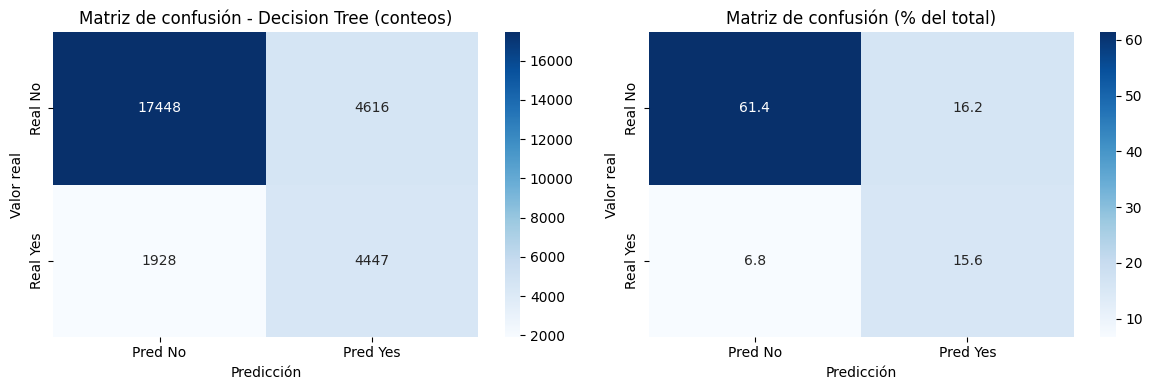

In [50]:
# Construimos la matriz de confusión para ver aciertos y errores por clase.
cm = confusion_matrix(y_test, y_pred)
# Porcentaje respecto al total de predicciones (los cuatro recuadros suman 100 %).
cm_pct = cm.astype(float) / cm.sum() * 100

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    ax=axes[0],
    xticklabels=["Pred No", "Pred Yes"],
    yticklabels=["Real No", "Real Yes"],
)
axes[0].set_title("Matriz de confusión - Decision Tree (conteos)")
axes[0].set_xlabel("Predicción")
axes[0].set_ylabel("Valor real")

sns.heatmap(
    cm_pct,
    annot=True,
    fmt=".1f",
    cmap="Blues",
    ax=axes[1],
    xticklabels=["Pred No", "Pred Yes"],
    yticklabels=["Real No", "Real Yes"],
)
axes[1].set_title("Matriz de confusión (% del total)")
axes[1].set_xlabel("Predicción")
axes[1].set_ylabel("Valor real")

plt.tight_layout()
plt.show()



## Resultado de la limpieza

Después de este punto ya tienes:

- columnas problemáticas eliminadas,
- `RainTomorrow` convertida a binaria,
- variables temporales creadas desde `Date`,
- imputación para nulos,
- codificación de variables categóricas,
- partición `train/test`,
- y el pipeline listo para entrenar y evaluar el árbol de decisión.

Con estas celdas ya puedes limpiar, entrenar y evaluar el modelo dentro del mismo notebook.